# LLaVA + CLIP Few-Shot Classification

- **LLaVA 1.5-7B** (Large Language and Vision Assistant): modello multimodale che genera descrizioni testuali ricche e dettagliate a partire da immagini, usato per costruire prototipi semantici per ogni classe.
- **CLIP ViT-L/14** (Contrastive Language–Image Pretraining): modello vision-language di OpenAI che opera in uno spazio condiviso testo-immagine, usato per estrarre feature visive e codificare le caption LLaVA in vettori.

**Idea chiave — prototipi ibridi:** anziché costruire un prototipo di classe calcolando la media delle feature visive delle immagini di support (approccio Prototypical Networks classico), LLaVA genera caption descrittive per ogni immagine di support, e CLIP le codifica nel suo spazio testuale. Il prototipo di classe è la media di questi embedding testuali. Le feature delle immagini di query vengono invece processate da un adapter trainabile che le raffina prima della classificazione.

**Pipeline completa:**
1. LLaVA genera caption per ogni classe → prototipi testuali tramite CLIP text encoder
2. CLIP estrae feature visive per tutto il dataset (salvate in cache su disco)
3. Un CLIP Adapter viene addestrato sulle feature cached per raffinare le rappresentazioni visive
4. Validazione episodica con prototipi **ibridi**: caption LLaVA per i support, adapter per le query
5. Confronto finale tra tutti i metodi su episodi sintetici 5-way 5-shot


## 0 — Setup GPU e import

Questa cella configura l'ambiente di esecuzione e importa tutte le librerie necessarie per la pipeline.

**Librerie importate:**
- `torch` / `torch.nn` / `torch.nn.functional`: framework deep learning per la definizione e il training dei modelli
- `clip`: libreria OpenAI per caricare e usare CLIP
- `PIL.Image`: caricamento e preprocessing delle immagini
- `tqdm`: barre di avanzamento per i cicli di elaborazione
- `numpy`, `pandas`: manipolazione di array e dataset CSV

**Percorsi configurati:**
- `CSV_PATH`: file CSV del training set con colonne `filename` e `label`
- `IMGS_DIR`: directory contenente le immagini originali del dataset AML
- `VAL_CSV`: file CSV degli episodi di validazione ufficiali
- `OUTPUT_DIR`: directory di output per cache, modelli e figure

La funzione `set_seed` fissa il seed per `random`, `numpy` e `torch` (incluso CUDA) garantendo riproducibilità degli esperimenti. Il device viene impostato automaticamente su GPU se disponibile.


In [1]:
#!/usr/bin/env python3
import os
import random
import copy
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm

import clip  # OpenAI CLIP

# ── Percorsi ──────────────────────────────────────────────────────────────────
CSV_PATH   = "AMLdataset/release/train.csv"
IMGS_DIR   = "AMLdataset/release/images"
VAL_CSV    = "AMLdataset/release/test_episodes_release.csv"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED = 42

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:  ", torch.cuda.get_device_name(0))
    print(f"VRAM:  {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


Device: cuda
GPU:   NVIDIA GeForce RTX 5070 Laptop GPU
VRAM:  8.5 GB


## 1 — Definizione del caricamento di CLIP ViT-L/14

Questa cella **definisce** (ma non esegue) la funzione `load_clip()` che carica il modello CLIP con backbone ViT-L/14.

Il caricamento dei modelli è differito sulla GPU da 8 GB, infatti è necessario caricare prima LLaVA e poi CLIP per non saturare la VRAM. La funzione viene chiamata nella cella successiva, dopo l'inizializzazione di LLaVA.

**Cosa fa `load_clip()`:**
- Carica i pesi di `ViT-L/14` in modalità inference (`eval()`)
- Congela tutti i parametri di CLIP (`requires_grad = False`) — CLIP non viene mai modificato
- Imposta la variabile globale `FEATURE_DIM` con la dimensione dell'embedding visivo (768 per ViT-L/14)
- Imposta `clip_preprocess`: la pipeline di preprocessing richiesta da CLIP (resize, crop, normalizzazione ImageNet)


In [2]:
# CLIP viene caricato DOPO LLaVA per ottimizzare l'utilizzo della VRAM
# Viene definita la funzione di caricamento e chiamata dopo LLaVA
def load_clip():
    global clip_model, clip_preprocess, FEATURE_DIM
    print("Caricando CLIP ViT-L/14...")
    clip_model, clip_preprocess = clip.load("ViT-L/14", DEVICE, jit=False)
    clip_model.eval()
    for p in clip_model.parameters():
        p.requires_grad = False
    FEATURE_DIM = clip_model.visual.output_dim
    print(f"CLIP caricato — feature dim: {FEATURE_DIM}")

# Non caricare CLIP ancora — lo facciamo dopo LLaVA
print("CLIP verra caricato dopo LLaVA per ottimizzare la VRAM.")


CLIP verra caricato dopo LLaVA per ottimizzare la VRAM.


## 2 — Caricamento di LLaVA 1.5-7B in quantizzazione 4-bit

Questa cella carica il modello LLaVA 1.5-7B utilizzando la quantizzazione **NF4 a 4-bit** tramite `BitsAndBytesConfig`, riducendo l'occupazione VRAM da ~14 GB a ~4-5 GB, compatibile con GPU consumer (RTX 5070 o superiore).

**Configurazione BitsAndBytes:**
- `load_in_4bit=True`: pesi compressi a 4 bit
- `bnb_4bit_compute_dtype=float16`: i calcoli avvengono in float16 per velocità
- `bnb_4bit_quant_type="nf4"`: quantizzazione NormalFloat4, ottimale per pesi Gaussiani
- `bnb_4bit_use_double_quant=True`: doppia quantizzazione per ulteriore risparmio di memoria (~0.4 bit/param aggiuntivi)

**Componenti caricati:**
- `llava_processor`: tokenizer + image processor integrati (gestisce sia testo che immagini)
- `llava_model`: il modello LLaVA completo in 4-bit, forzato tutto su `cuda:0`

Al termine del caricamento di LLaVA viene invocata `load_clip()` per caricare CLIP nello spazio VRAM rimanente. La cella stampa l'utilizzo VRAM prima e dopo per monitorare il consumo.


In [3]:
from transformers import (
    LlavaForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)
import gc

LLAVA_MODEL_ID = "llava-hf/llava-1.5-7b-hf"

# Pulisci la VRAM prima di caricare LLaVA
gc.collect()
torch.cuda.empty_cache()
used  = torch.cuda.memory_allocated() / 1e9
total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"VRAM disponibile prima di LLaVA: {total - used:.1f} / {total:.1f} GB")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

print(f"Caricando {LLAVA_MODEL_ID} in 4-bit...")
llava_processor = AutoProcessor.from_pretrained(LLAVA_MODEL_ID)
llava_model = LlavaForConditionalGeneration.from_pretrained(
    LLAVA_MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0},   # forza tutto su cuda:0
    torch_dtype=torch.float16,
)
llava_model.eval()
print("LLaVA pronto!")

# Ora carica CLIP
load_clip()

used  = torch.cuda.memory_allocated() / 1e9
total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"VRAM in uso (LLaVA + CLIP): {used:.1f} / {total:.1f} GB")


VRAM disponibile prima di LLaVA: 8.5 / 8.5 GB
Caricando llava-hf/llava-1.5-7b-hf in 4-bit...


W0525 11:30:24.719000 30796 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

LLaVA pronto!
Caricando CLIP ViT-L/14...
CLIP caricato — feature dim: 768
VRAM in uso (LLaVA + CLIP): 5.0 / 8.5 GB


## 3 — Definizione dei Dataset

Questa cella definisce due classi Dataset personalizzate e istanzia i DataLoader per training e test.

**`AMLDataset`** — dataset principale:
- Legge il CSV e applica uno split stratificato 80/20 per classe (garantisce distribuzione bilanciata)
- Supporta percorsi sia relativi (immagini originali) che assoluti (immagini aumentate)
- Applica `clip_preprocess` come trasformazione: resize a 224×224, crop centrale, normalizzazione ImageNet
- Espone `classes`, `class_to_idx`, `idx_to_class` per la mappatura indice ↔ nome classe

**`AMLValidation`** — dataset episodico per la validazione ufficiale:
- Legge `test_episodes_release.csv` che definisce episodi predefiniti con ruoli `support` / `query`
- `__getitem__` restituisce un dizionario con i percorsi delle immagini di support e query per ogni episodio

**DataLoader configurati:**
- `train_loader`: batch size 32, shuffle attivo, drop_last per batch uniformi
- `test_loader`: batch size 32, shuffle disattivato, drop_last
- `val_loader`: batch size 1 (un episodio alla volta), usato solo se il CSV di validazione esiste


In [ ]:
from sklearn.model_selection import train_test_split


class AMLDataset(Dataset):
    def __init__(self, csv_path, imgs_dir, train=True, transform=None):
        self.imgs_dir  = imgs_dir
        self.transform = transform

        full_df = pd.read_csv(csv_path)
        train_df, test_df = train_test_split(
            full_df, test_size=0.20, random_state=42, stratify=full_df["label"]
        )
        train_df = full_df

        self.df           = (train_df if train else test_df).reset_index(drop=True)
        self.classes      = sorted(self.df["label"].unique().tolist())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.idx_to_class = {i: c for c, i in self.class_to_idx.items()}
        self.labels       = [self.class_to_idx[n] for n in self.df["label"]]

    def __len__(self):
        return len(self.df)

    # Caricamento delle immagini (funziona acnhe con i path assoluti)
    def _resolve_path(self, filename):
        if os.path.isabs(filename) or os.path.exists(filename):
            return filename
        return os.path.join(self.imgs_dir, str(filename))

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        path = self._resolve_path(row["filename"])
        img  = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


class AMLValidation(Dataset):
    def __init__(self, csv_path, imgs_dir):
        self.df          = pd.read_csv(csv_path)
        self.imgs_dir    = imgs_dir
        self.episode_ids = sorted(self.df["episode_id"].unique())

    def __len__(self):
        return len(self.episode_ids)

    def __getitem__(self, idx):
        ep_id      = self.episode_ids[idx]
        ep_df      = self.df[self.df["episode_id"] == ep_id]
        support_df = ep_df[ep_df["role"] == "support"]
        query_df   = ep_df[ep_df["role"] == "query"]
        return {
            "support_imgs":   [f"{self.imgs_dir}/{f}" for f in support_df["filename"]],
            "support_labels": support_df["label"].values,
            "query_imgs":     [f"{self.imgs_dir}/{f}" for f in query_df["filename"]],
            "episode_id":     ep_id,
        }

# Crea i DataLoader per train/test e opzionalmente per la validazione episodica
train_dataset = AMLDataset(CSV_PATH, IMGS_DIR, train=True,  transform=clip_preprocess)
test_dataset  = AMLDataset(CSV_PATH, IMGS_DIR, train=False, transform=clip_preprocess)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  drop_last=True,
                          pin_memory=True, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, drop_last=True,
                          pin_memory=True, num_workers=0)

if os.path.exists(VAL_CSV):
    val_dataset = AMLValidation(VAL_CSV, IMGS_DIR)
    val_loader  = DataLoader(val_dataset, batch_size=1, shuffle=False)
    print(f"Val episodes: {len(val_dataset)}")
else:
    val_loader = None
    print(f"[WARNING] {VAL_CSV} non trovato")

NUM_CLASSES = len(train_dataset.classes)
print(f"Classi: {NUM_CLASSES} | Train: {len(train_dataset)} | Test: {len(test_dataset)}")


Val episodes: 20
Classi: 250 | Train: 5000 | Test: 1000


## 3b — Data Augmentation offline (salva su disco)

Questa cella genera versioni aumentate di tutte le immagini del training set e le salva fisicamente su disco, aggiornando il CSV per includere le nuove righe. Il risultato è un dataset **triplicato** (originale + 2 aumentate per ogni immagine).

**Trasformazioni applicate a ogni immagine:**
- `RandomHorizontalFlip(p=0.5)`: ribaltamento orizzontale con probabilità 50%
- `RandomVerticalFlip(p=0.5)`: ribaltamento verticale con probabilità 50%
- `RandomRotation(±10°)`: rotazione casuale entro ±10 gradi
- `ColorJitter`: perturbazione casuale di luminosità (±20%), contrasto (±20%), saturazione (±20%) e tonalità (±5%)

**Dettagli implementativi:**
- Le immagini originali vengono salvate con percorso assoluto nel nuovo CSV
- Le immagini aumentate vengono salvate in `AMLdataset/release/images_augmentation/` con prefisso `aug_j_`
- Il CSV aumentato viene scritto in `train_augmented.csv`
- **Controllo di idempotenza:** se il CSV esiste già, la cella viene saltata per evitare di rigenerare migliaia di immagini
- Al termine, `CSV_PATH` viene aggiornato al CSV aumentato per le celle successive

Eseguire questa cella **una sola volta**. Per rigenerare, elimina manualmente `train_augmented.csv`.


In [5]:
import csv
from torchvision.transforms import v2
from torchvision.io import read_image

AUGMENTED_CSV_PATH = "AMLdataset/release/train_augmented.csv"
IMGS_AUG_DIR       = "AMLdataset/release/images_augmentation"
N_AUGMENTATIONS    = 2

os.makedirs(IMGS_AUG_DIR, exist_ok=True)

if os.path.exists(AUGMENTED_CSV_PATH):
    print(f"CSV aumentato gia esistente: {AUGMENTED_CSV_PATH}")
    print("Salto la generazione. Elimina il file per rigenerare.")
else:
    aug_transform = v2.Compose([
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomVerticalFlip(p=0.5),
        v2.RandomRotation(degrees=10),
        v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        v2.ToDtype(torch.float32, scale=True),
    ])

    augmented_rows = []

    with open(CSV_PATH, "r") as f:
        reader = csv.reader(f)
        header = next(reader)
        rows   = list(reader)

    augmented_rows.append(header)

    print(f"Generando {N_AUGMENTATIONS} augmentazioni per {len(rows)} immagini...")
    print(f"Immagini originali salvate in: {IMGS_DIR}")
    print(f"Immagini aumentate salvate in: {IMGS_AUG_DIR}")
    print(f"Totale immagini finali: {len(rows) * (N_AUGMENTATIONS + 1)}")

    for i, row in enumerate(tqdm(rows, desc="Augmentation")):
        img_filename = row[0]
        img_label    = row[1]
        img_path     = os.path.join(IMGS_DIR, img_filename)

        # Aggiungi immagine originale (percorso nella cartella originale)
        augmented_rows.append([os.path.join(IMGS_DIR, img_filename), img_label])

        # Genera N versioni aumentate e salvale in images_augmentation
        try:
            img_tensor = read_image(img_path)

            for j in range(N_AUGMENTATIONS):
                aug_tensor = aug_transform(img_tensor)
                aug_pil    = Image.fromarray(
                    (aug_tensor.permute(1, 2, 0).numpy() * 255).astype("uint8")
                )
                aug_filename = f"aug_{j}_{img_filename}"
                aug_path     = os.path.join(IMGS_AUG_DIR, aug_filename)
                aug_pil.save(aug_path, format="JPEG")
                # Nel CSV salva il percorso completo cosi il dataset lo trova
                augmented_rows.append([aug_path, img_label])

        except Exception as e:
            print(f"\n[WARN] Skipped {img_filename}: {e}")
            continue

    with open(AUGMENTED_CSV_PATH, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerows(augmented_rows)

    print(f"\nSalvato: {AUGMENTED_CSV_PATH}")
    print(f"Righe totali: {len(augmented_rows) - 1}")

# Aggiorna CSV_PATH per usare il dataset aumentato
CSV_PATH = AUGMENTED_CSV_PATH
print(f"\nCSV_PATH aggiornato a: {CSV_PATH}")


Generando 2 augmentazioni per 5000 immagini...
Immagini originali salvate in: AMLdataset/release/images
Immagini aumentate salvate in: AMLdataset/release/images_augmentation
Totale immagini finali: 15000


Augmentation:   0%|          | 0/5000 [00:00<?, ?it/s]


[WARN] Skipped images_60.jpg: Cannot handle this data type: (1, 1, 1), |u1

[WARN] Skipped images_155.jpg: Cannot handle this data type: (1, 1, 1), |u1

[WARN] Skipped images_1248.jpg: Cannot handle this data type: (1, 1, 1), |u1

[WARN] Skipped images_1286.jpg: Cannot handle this data type: (1, 1, 1), |u1

[WARN] Skipped images_1580.jpg: Cannot handle this data type: (1, 1, 1), |u1

[WARN] Skipped images_2340.jpg: Cannot handle this data type: (1, 1, 1), |u1

[WARN] Skipped images_3312.jpg: Cannot handle this data type: (1, 1, 1), |u1

[WARN] Skipped images_3538.jpg: Cannot handle this data type: (1, 1, 1), |u1

[WARN] Skipped images_4592.jpg: Cannot handle this data type: (1, 1, 1), |u1

Salvato: AMLdataset/release/train_augmented.csv
Righe totali: 14982

CSV_PATH aggiornato a: AMLdataset/release/train_augmented.csv


## 4 — Definizione delle funzioni di utilità

Questa cella raccoglie tutte le funzioni helper

**Funzioni di encoding:**
- `encode_images(model, images)`: estrae feature visive con CLIP e le L2-normalizza; eseguita con `@torch.no_grad()` per efficienza
- `encode_text_tokens(model, tokens)`: codifica token testuali con CLIP text encoder e L2-normalizza

**Metriche:**
- `accuracy_from_logits(logits, labels)`: calcola l'accuratezza come percentuale di predizioni corrette (argmax dei logit)

**Captioning LLaVA:**
- `LLAVA_PROMPT`: template del prompt nel formato `USER: <image>\n...\nASSISTANT:` richiesto da LLaVA 1.5
- `_is_looping(caption)`: rilevamento di caption degenerate (ripetizione di tre parole consecutive) — filtra output patologici del modello
- `llava_caption(pil_img, ...)`: genera una caption per un'immagine PIL; usa `do_sample=False` (greedy decoding) per output deterministici; scarta i token del prompt dall'output

**Training loop su feature cached:**
- `train_on_cached_features(...)`: loop di training completo per modelli lineari o adapter su feature pre-estratte
  - Ottimizzatore AdamW con weight decay 0.1
  - Scheduler Cosine Annealing per il learning rate
  - Gradient clipping a norma 1.0
  - Early stopping con patience configurabile
  - Restituisce l'accuratezza migliore raggiunta sul test set


In [ ]:
# Encode
@torch.no_grad()
def encode_images(model, images):
    return F.normalize(model.encode_image(images).float(), dim=-1)

@torch.no_grad()
def encode_text_tokens(model, tokens):
    return F.normalize(model.encode_text(tokens).float(), dim=-1)

def accuracy_from_logits(logits, labels):
    return (logits.argmax(dim=1) == labels).float().mean().item() * 100

# LLaVA captioning description prompt: promt che si può modificare in base a come si vuole avere la descrizione dell'immagine
LLAVA_PROMPT = (
    "USER: <image>\n"
    "Describe this image in detail: the main subject, its color, texture, shape, "
    "and any distinguishing visual features. Be specific and concise.\n"
    "ASSISTANT:"
)

def _is_looping(caption: str, window: int = 3) -> bool:
    words = caption.split()
    return any(
        words[j] == words[j+1] == words[j+2]
        for j in range(len(words) - window + 1)
    ) if len(words) >= window else False

@torch.no_grad()
def llava_caption(pil_img, processor, model, max_new_tokens=60):
    inputs = processor(
        text=LLAVA_PROMPT, images=pil_img, return_tensors="pt"
    ).to(DEVICE, torch.float16)
    out = model.generate(
        **inputs, max_new_tokens=max_new_tokens,
        do_sample=False, temperature=None, top_p=None,
    )
    n_prompt  = inputs["input_ids"].shape[1]
    generated = out[0][n_prompt:]
    return processor.tokenizer.decode(generated, skip_special_tokens=True).strip()

# Training loop su feature cached
def train_on_cached_features(
    model, train_features, train_labels, test_features, test_labels,
    epochs=1000, lr=1e-3, batch_size=256, patience=20, name="Model",
):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=0.1,
    )
    # Cosine LR decay
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )
    loss_fn = nn.CrossEntropyLoss()

    tf = train_features.to(DEVICE)
    tl = train_labels.to(DEVICE)
    ef = test_features.to(DEVICE)
    el = test_labels.to(DEVICE)

    best_acc, best_weights, no_improve, n = 0.0, None, 0, tf.shape[0]

    for epoch in range(epochs):
        model.train()
        perm, total_loss = torch.randperm(n, device=DEVICE), 0.0
        for start in range(0, n, batch_size):
            idx    = perm[start:start + batch_size]
            logits = model(tf[idx])
            loss   = loss_fn(logits, tl[idx])
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * idx.numel()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            acc = accuracy_from_logits(model(ef), el)

        print(f"{name} | epoch {epoch+1:04d}/{epochs} | "
              f"loss {total_loss/n:.4f} | acc {acc:.2f}%")

        if acc > best_acc:
            best_acc, best_weights, no_improve = acc, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping a epoch {epoch+1} — best: {best_acc:.2f}%")
                break

    model.load_state_dict(best_weights)
    return best_acc

print("Funzioni di utilità caricate!")


Funzioni di utilità caricate!


## 4b — Visualizzazione: 5 immagini casuali con caption LLaVA e predizione zero-shot CLIP

Questa cella definisce ed esegue una visualizzazione diagnostica che permette di ispezionare qualitativamente il comportamento congiunto di LLaVA e CLIP prima di qualsiasi training.

**Per ognuna delle 5 immagini campionate casualmente dal training set, vengono mostrati:**
- L'immagine originale
- La **caption generata da LLaVA** in tempo reale (greedy decoding, max 60 token)
- La **label reale** della classe
- La **predizione zero-shot di CLIP**: calcolata confrontando la feature visiva dell'immagine con i prototipi testuali di tutte le classi, costruiti con 3 template (`"a photo of a {}"`, `"a close-up photo of a {}"`, `"a detailed photo of a {}"`)

**Codifica visiva del risultato:**
- **Scritte verdei** `#2ecc71`: predizione zero-shot corretta
- **Scritte rosse** `#e74c3c`: predizione zero-shot errata

La figura viene salvata in `outputs/sample_predictions.png`.


Calcolando prototipi zero-shot CLIP...
Generando caption per classe 211...
Generando caption per classe 314...
Generando caption per classe 178...
Generando caption per classe 165...
Generando caption per classe 11...


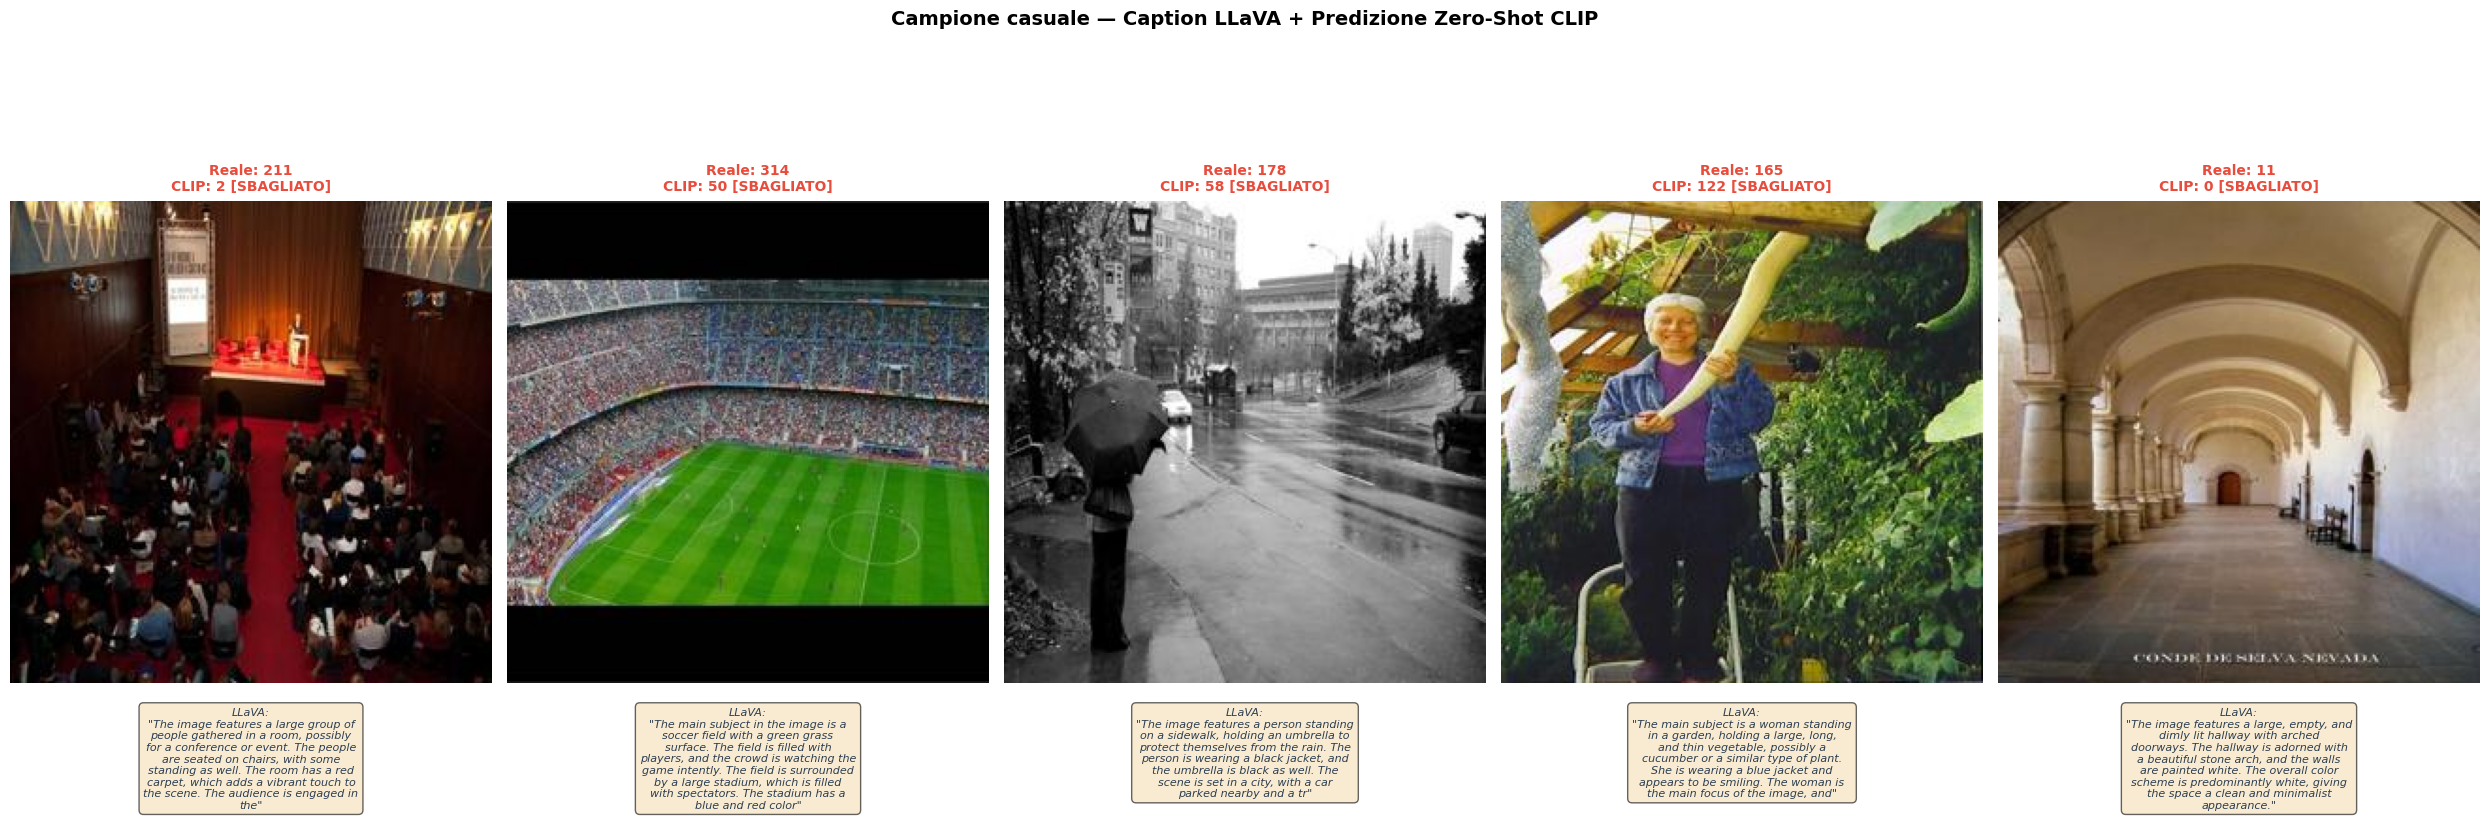


Salvato in outputs/sample_predictions.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import textwrap

@torch.no_grad()
def show_random_predictions(dataset, clip_model, llava_model, llava_processor,
                             n_images=5, seed=None):
    """
    Mostra n_images immagini casuali con:
    - caption LLaVA generata in tempo reale
    - label reale
    - predizione zero-shot CLIP (verde=corretta, rosso=sbagliata)
    """
    if seed is not None:
        random.seed(seed)

    clip_model.eval()
    llava_model.eval()

    # Prototipi testuali per tutte le classi (zero-shot CLIP con template)
    print("Calcolando prototipi zero-shot CLIP...")
    templates = [
        "a photo of a {}.",
        "a close-up photo of a {}.",
        "a detailed photo of a {}.",
    ]
    all_text_feats = []
    for cls_name in dataset.classes:
        prompts = [t.format(cls_name) for t in templates]
        tokens  = clip.tokenize(prompts, truncate=True).to(DEVICE)
        feats   = encode_text_tokens(clip_model, tokens).mean(dim=0)
        all_text_feats.append(F.normalize(feats, dim=-1))
    text_prototypes = torch.stack(all_text_feats)  # [num_classes, 768]

    # Scegli n_images indici casuali
    indices = random.sample(range(len(dataset)), n_images)

    fig, axes = plt.subplots(1, n_images, figsize=(5 * n_images, 8))
    if n_images == 1:
        axes = [axes]

    fig.suptitle("Campione casuale — Caption LLaVA + Predizione Zero-Shot CLIP",
                 fontsize=14, fontweight="bold", y=1.02)

    for ax, idx in zip(axes, indices):
        row      = dataset.df.iloc[idx]
        path     = dataset._resolve_path(row["filename"])
        pil_img  = Image.open(path).convert("RGB")
        true_cls = dataset.idx_to_class[dataset.labels[idx]]

        # Caption LLaVA
        print(f"Generando caption per classe {true_cls}...")
        caption = llava_caption(pil_img, llava_processor, llava_model)

        # Predizione zero-shot CLIP
        img_tensor = clip_preprocess(pil_img).unsqueeze(0).to(DEVICE)
        img_feat   = encode_images(clip_model, img_tensor)
        logits     = 100.0 * img_feat @ text_prototypes.T
        pred_idx   = logits.argmax(dim=-1).item()
        pred_cls   = dataset.idx_to_class[pred_idx]
        correct    = (pred_idx == dataset.labels[idx])

        # Plot
        ax.imshow(pil_img)
        ax.axis("off")

        # Bordo colorato
        color = "#2ecc71" if correct else "#e74c3c"
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(color)
            spine.set_linewidth(6)

        # Titolo con label reale e predizione
        status = "CORRETTO" if correct else "SBAGLIATO"
        ax.set_title(
            f"Reale: {true_cls}\nCLIP: {pred_cls} [{status}]",
            color=color, fontsize=10, fontweight="bold", pad=8
        )

        # Caption LLaVA in basso
        wrapped = "\n".join(textwrap.wrap(caption, width=38))
        ax.text(
            0.5, -0.05,
            f'LLaVA:\n"{wrapped}"',
            color="#2c3e50", ha="center", va="top",
            transform=ax.transAxes, fontsize=8, style="italic",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="wheat", alpha=0.6),
        )

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "sample_predictions.png"),
                bbox_inches="tight", dpi=120)
    plt.show()
    print("\nSalvato in outputs/sample_predictions.png")


# ── Lancia la visualizzazione ─────────────────────────────────────────────────
show_random_predictions(
    train_dataset,
    clip_model,
    llava_model,
    llava_processor,
    n_images=5,
    seed=SEED,
)


## 5 — Costruzione dei prototipi testuali con LLaVA

Questa cella costruisce un prototipo testuale per ogni classe del dataset, usando LLaVA come captioner e CLIP come encoder testuale.

**Procedura per ogni classe:**
1. Si selezionano fino a `images_per_class=5` immagini di quella classe dal training set
2. LLaVA genera una caption descrittiva per ciascuna immagine (greedy decoding)
3. Le caption con loop lessicale vengono scartate da `_is_looping()`
4. Le caption valide vengono tokenizzate e codificate dal CLIP text encoder
5. Le embedding testuali vengono mediate e L2-normalizzate → **prototipo della classe** (vettore 768-dim)

**Output:** tensore `llava_text_features` di shape `[num_classes, 768]`, dove ogni riga è il prototipo testuale di una classe.

**Cache su disco:** i prototipi vengono salvati in `outputs/llava_text_features.pt`. Se il file esiste già, viene caricato direttamente senza rieseguire il captioning. Per rigenerare i prototipi, elimina il file di cache.


In [8]:
@torch.no_grad()
def build_llava_text_features(dataset, clip_model, llava_model, llava_processor,
                               images_per_class=5):
    """
    Per ogni classe:
      1. LLaVA genera caption da N immagini
      2. CLIP text encoder codifica le caption
      3. Media L2-normalizzata → prototipo [num_classes, 768]
    """
    class_to_indices = {}
    for idx, label in enumerate(dataset.labels):
        class_to_indices.setdefault(label, []).append(idx)

    all_features = []
    for class_idx in tqdm(range(len(dataset.classes)), desc="LLaVA captioning"):
        indices  = class_to_indices[class_idx][:images_per_class]
        captions = []
        for i in indices:
            row = dataset.df.iloc[i]
            path    = os.path.join(dataset.imgs_dir, str(row["filename"]))
            pil_img = Image.open(path).convert("RGB")
            caption = llava_caption(pil_img, llava_processor, llava_model)
            if not _is_looping(caption):
                captions.append(caption)

        if len(captions) == 0:
            captions = ["a photo of an object"]

        tokens    = clip.tokenize(captions, truncate=True).to(DEVICE)
        features  = encode_text_tokens(clip_model, tokens)
        prototype = F.normalize(features.mean(dim=0), dim=-1)
        all_features.append(prototype)

    return torch.stack(all_features)   # [num_classes, 768]


CACHE_TEXT = os.path.join(OUTPUT_DIR, "llava_text_features.pt")

if os.path.exists(CACHE_TEXT):
    print(f"Caricando prototipi LLaVA da {CACHE_TEXT}...")
    llava_text_features = torch.load(CACHE_TEXT).to(DEVICE)
else:
    llava_text_features = build_llava_text_features(
        train_dataset, clip_model, llava_model, llava_processor,
        images_per_class=5,
    )
    torch.save(llava_text_features.cpu(), CACHE_TEXT)
    print(f"Salvato in {CACHE_TEXT}")

print("Shape prototipi LLaVA:", llava_text_features.shape)  # [250, 768]


Caricando prototipi LLaVA da outputs\llava_text_features.pt...
Shape prototipi LLaVA: torch.Size([250, 768])


## 6 — Estrazione e cache delle feature visive CLIP

Questa cella estrae le feature visive di tutte le immagini del training e del test set con CLIP ViT-L/14, e le salva su disco per evitare di rieseguire la forward pass ad ogni esperimento.

**Funzione `extract_clip_features`:**
- Itera sui batch del DataLoader passato
- Per ogni batch, esegue la forward pass del visual encoder di CLIP con `@torch.no_grad()`
- L2-normalizza le feature estratte
- Mostra una barra di avanzamento testuale personalizzata

**Feature estratte:**
- `train_features`: shape `[N_train, 768]` — feature di tutte le immagini di training
- `train_labels`: shape `[N_train]` — label corrispondenti (indici interi)
- `test_features` / `test_labels`: analoghi per il test set

**Cache:** tutto viene salvato in `outputs/clip_features.pt` come dizionario. Se il file esiste, viene caricato direttamente. Questo è fondamentale per velocizzare l'addestramento del Linear Probe e dell'Adapter, che operano interamente sulle feature precompute senza mai rieseguire CLIP.


In [9]:
@torch.no_grad()
def extract_clip_features(model, loader, desc="CLIP features"):
    all_features, all_labels = [], []
    n = len(loader)
    print(f"Batch totali: {n}")
    for i, (images, labels) in enumerate(loader):
        images   = images.to(DEVICE)
        features = encode_images(model, images)
        all_features.append(features.cpu())
        all_labels.append(labels.cpu())
        barra = "█" * int((i+1)/n*30)
        sys.stdout.write(f"\rBatch {i+1}/{n} [{barra:<30}] {(i+1)/n*100:.1f}%")
        sys.stdout.flush()
    sys.stdout.write("\nFatto!\n")
    return torch.cat(all_features), torch.cat(all_labels)


CACHE_VIS = os.path.join(OUTPUT_DIR, "clip_features.pt")

if os.path.exists(CACHE_VIS):
    print(f"Caricando feature visive da {CACHE_VIS}...")
    ckpt           = torch.load(CACHE_VIS)
    train_features = ckpt["train_features"]
    train_labels   = ckpt["train_labels"]
    test_features  = ckpt["test_features"]
    test_labels    = ckpt["test_labels"]
else:
    print("Estrazione feature Train...")
    train_features, train_labels = extract_clip_features(clip_model, train_loader, "Train")
    print("Estrazione feature Test...")
    test_features, test_labels   = extract_clip_features(clip_model, test_loader,  "Test")
    torch.save({
        "train_features": train_features, "train_labels": train_labels,
        "test_features":  test_features,  "test_labels":  test_labels,
    }, CACHE_VIS)
    print(f"Salvato in {CACHE_VIS}")

print("Train:", train_features.shape)
print("Test: ", test_features.shape)
print("Dim:  ", train_features.shape[1])


Caricando feature visive da outputs\clip_features.pt...
Train: torch.Size([4992, 768])
Test:  torch.Size([992, 768])
Dim:   768


## 7 — Baseline zero-shot con prototipi LLaVA

Questa cella valuta il metodo **zero-shot** puro: classifica le immagini del test set confrontando le loro feature visive CLIP (estratte nella cella 6) con i prototipi testuali LLaVA (costruiti nella cella 5), senza alcun training.

**Come funziona:**
- Per ogni immagine di test, si calcola la cosine similarity (scalata di 100×) tra la sua feature visiva e tutti i prototipi testuali
- La classe con similarity massima è la predizione

**Significato:** questa baseline misura quanto bene lo spazio condiviso testo-immagine di CLIP allinea naturalmente le descrizioni generate da LLaVA con le feature visive corrispondenti. È il punto di partenza — tutte le varianti con training dovranno superarlo.

Il risultato `zs_acc` viene stampato e riutilizzato nel confronto finale.


In [10]:
with torch.no_grad():
    zs_logits = 100.0 * test_features.to(DEVICE) @ llava_text_features.T
    zs_acc    = accuracy_from_logits(zs_logits, test_labels.to(DEVICE))

print(f"Zero-shot LLaVA: {zs_acc:.2f}%")


Zero-shot LLaVA: 44.76%


## 8 — Linear Probe (baseline con training)

Questa cella addestra un **classificatore lineare** (`LinearProbe`) sopra le feature CLIP congelate, come seconda baseline con training.

**Architettura `LinearProbe`:**
- Un unico layer `nn.Linear(FEATURE_DIM, NUM_CLASSES, bias=False)`
- Le feature in input vengono L2-normalizzate prima della moltiplicazione matriciale

**Training:**
- Eseguito con `train_on_cached_features` sulle feature precompute (nessuna forward pass CLIP)
- 1000 epoche massime, early stopping con patience=20, AdamW + Cosine LR
- I pesi migliori vengono salvati in `outputs/linear_probe.pt`

**Significato:** il Linear Probe misura la qualità delle feature CLIP "raw" per il task di classificazione, senza adattamento architetturale. È la baseline trainata di riferimento: un metodo più espressivo (l'Adapter) dovrebbe superarlo sfruttando la non-linearità aggiuntiva.


In [11]:
class LinearProbe(nn.Module):
    def __init__(self, feature_dim, num_classes):
        super().__init__()
        self.classifier = nn.Linear(feature_dim, num_classes, bias=False)
    def forward(self, x):
        return self.classifier(F.normalize(x.float(), dim=-1))


linear_probe = LinearProbe(FEATURE_DIM, NUM_CLASSES)

lp_acc = train_on_cached_features(
    linear_probe,
    train_features, train_labels,
    test_features,  test_labels,
    epochs=1000, lr=1e-3, batch_size=256, patience=20,
    name="Linear Probe",
)
print(f"\nAccuracy Linear Probe: {lp_acc:.2f}%")

torch.save(linear_probe.cpu().state_dict(),
           os.path.join(OUTPUT_DIR, "linear_probe.pt"))
linear_probe = linear_probe.to(DEVICE)


Linear Probe | epoch 0001/1000 | loss 5.4983 | acc 34.27%
Linear Probe | epoch 0002/1000 | loss 5.4263 | acc 55.04%
Linear Probe | epoch 0003/1000 | loss 5.3592 | acc 61.49%
Linear Probe | epoch 0004/1000 | loss 5.2929 | acc 66.43%
Linear Probe | epoch 0005/1000 | loss 5.2273 | acc 67.04%
Linear Probe | epoch 0006/1000 | loss 5.1621 | acc 68.75%
Linear Probe | epoch 0007/1000 | loss 5.0975 | acc 70.26%
Linear Probe | epoch 0008/1000 | loss 5.0335 | acc 70.36%
Linear Probe | epoch 0009/1000 | loss 4.9699 | acc 71.17%
Linear Probe | epoch 0010/1000 | loss 4.9071 | acc 71.57%
Linear Probe | epoch 0011/1000 | loss 4.8445 | acc 71.67%
Linear Probe | epoch 0012/1000 | loss 4.7826 | acc 71.57%
Linear Probe | epoch 0013/1000 | loss 4.7214 | acc 71.77%
Linear Probe | epoch 0014/1000 | loss 4.6606 | acc 71.67%
Linear Probe | epoch 0015/1000 | loss 4.6001 | acc 71.67%
Linear Probe | epoch 0016/1000 | loss 4.5407 | acc 71.77%
Linear Probe | epoch 0017/1000 | loss 4.4814 | acc 71.77%
Linear Probe |

## 9 — CLIP Adapter con prototipi LLaVA

Questa cella definisce e addestra un **CLIP Adapter**: un modulo leggero e trainabile interposto tra le feature CLIP e la classificazione, che raffina le rappresentazioni visive senza toccare i pesi di CLIP.

**Architettura `CLIPAdapter` (bottleneck residuale):**
- `Linear(D → D/r)` → `ReLU` → `Linear(D/r → D)` con fattore di riduzione `r=4` (D=768 → hidden=192)
- **Residual mixing:** `output = (1 - α) * input + α * adapter(input)` con `α=0.2`
- L'output viene L2-normalizzato

**`CLIPAdapterClassifier`:**
- Combina l'adapter con i prototipi testuali LLaVA (registrati come buffer fisso, non trainabili)
- Classificazione: `logit_scale × adapter(visual_feat) @ text_prototypes.T`
- Solo i pesi dell'adapter vengono ottimizzati

**Training:** stesse impostazioni del Linear Probe (AdamW, Cosine LR, early stopping). I pesi vengono salvati in `outputs/clip_adapter.pt`.

In [12]:
class CLIPAdapter(nn.Module):
    """
    Bottleneck adapter: Linear(d→d/r) → ReLU → Linear(d/r→d)
    Residual mixing: output = (1-alpha)*input + alpha*adapter(input)
    """
    def __init__(self, feature_dim, reduction=4, alpha=0.2):
        super().__init__()
        hidden = max(1, feature_dim // reduction)
        self.net   = nn.Sequential(
            nn.Linear(feature_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, feature_dim),
        )
        self.alpha = alpha

    def forward(self, x):
        return F.normalize((1 - self.alpha) * x + self.alpha * self.net(x), dim=-1)


class CLIPAdapterClassifier(nn.Module):
    """
    CLIP frozen + Adapter trainabile + text features LLaVA come prototipi.
    """
    def __init__(self, feature_dim, num_classes, text_features,
                 reduction=4, alpha=0.2, logit_scale=100.0):
        super().__init__()
        self.adapter     = CLIPAdapter(feature_dim, reduction, alpha)
        self.alpha       = alpha
        self.logit_scale = logit_scale
        self.register_buffer("text_features",
                             F.normalize(text_features.float(), dim=-1))

    def forward(self, x):
        x = F.normalize(x.float(), dim=-1)
        return self.logit_scale * self.adapter(x) @ self.text_features.T


adapter_clf = CLIPAdapterClassifier(
    feature_dim   = FEATURE_DIM,
    num_classes   = NUM_CLASSES,
    text_features = llava_text_features.cpu(),   # prototipi LLaVA!
    reduction     = 4,
    alpha         = 0.2,
    logit_scale   = 100.0,
)

adapter_acc = train_on_cached_features(
    adapter_clf,
    train_features, train_labels,
    test_features,  test_labels,
    epochs=1000, lr=1e-4, batch_size=256, patience=20,
    name="CLIP+Adapter",
)
print(f"\nAccuracy CLIP+Adapter: {adapter_acc:.2f}%")

torch.save(adapter_clf.cpu().state_dict(),
           os.path.join(OUTPUT_DIR, "clip_adapter.pt"))
adapter_clf = adapter_clf.to(DEVICE)


CLIP+Adapter | epoch 0001/1000 | loss 2.6825 | acc 44.35%
CLIP+Adapter | epoch 0002/1000 | loss 2.5738 | acc 45.26%
CLIP+Adapter | epoch 0003/1000 | loss 2.4974 | acc 46.77%
CLIP+Adapter | epoch 0004/1000 | loss 2.4329 | acc 47.58%
CLIP+Adapter | epoch 0005/1000 | loss 2.3752 | acc 47.98%
CLIP+Adapter | epoch 0006/1000 | loss 2.3243 | acc 48.08%
CLIP+Adapter | epoch 0007/1000 | loss 2.2778 | acc 48.69%
CLIP+Adapter | epoch 0008/1000 | loss 2.2361 | acc 48.99%
CLIP+Adapter | epoch 0009/1000 | loss 2.1963 | acc 49.90%
CLIP+Adapter | epoch 0010/1000 | loss 2.1599 | acc 50.40%
CLIP+Adapter | epoch 0011/1000 | loss 2.1247 | acc 50.91%
CLIP+Adapter | epoch 0012/1000 | loss 2.0929 | acc 51.01%
CLIP+Adapter | epoch 0013/1000 | loss 2.0625 | acc 51.51%
CLIP+Adapter | epoch 0014/1000 | loss 2.0346 | acc 51.81%
CLIP+Adapter | epoch 0015/1000 | loss 2.0076 | acc 51.81%
CLIP+Adapter | epoch 0016/1000 | loss 1.9799 | acc 52.52%
CLIP+Adapter | epoch 0017/1000 | loss 1.9540 | acc 53.23%
CLIP+Adapter |

## 10 — Validazione episodica con metodo ibrido (LLaVA + Adapter)

Questa cella esegue la validazione **ufficiale** sul dataset episodico (`test_episodes_release.csv`), usando il metodo ibrido finale che combina LLaVA per i prototipi e l'Adapter per le feature di query.

**Procedura per ogni episodio:**
1. **Prototipi di classe:** LLaVA genera caption per ciascuna immagine di support → CLIP text encoder le codifica → media L2-normalizzata per ogni classe → tensore `text_protos` di shape `[n_way, 768]`
2. **Feature query:** CLIP visivo estrae le feature delle immagini di query → l'Adapter le trasforma con il residual mixing (`α=0.2`)
3. **Classificazione:** cosine similarity (×100) tra query adattate e prototipi testuali → argmax → predizione

**Output:** file CSV `outputs/hybrid_predictions.csv` con colonne `Id` (indice progressivo della query) e `label` (indice della classe predetta), nel formato richiesto dalla valutazione ufficiale.

> Questa cella viene eseguita solo se `val_loader` è disponibile (file `VAL_CSV` presente).


In [13]:
@torch.no_grad()
def run_hybrid_episodic(val_loader, clip_model, adapter_clf,
                         llava_model, llava_processor):
    """
    Validazione episodica ibrida: LLaVA per i prototipi,
    adapter per le feature delle query.
    """
    clip_model.eval()
    adapter_clf.eval()
    llava_model.eval()

    all_predictions = []
    query_id        = 0

    for batch in tqdm(val_loader, desc="[Hybrid episodic]"):
        s_imgs_paths = [p[0] for p in batch["support_imgs"]]
        s_labels_raw = batch["support_labels"].squeeze(0).long()
        q_imgs_paths = [p[0] for p in batch["query_imgs"]]
        unique_labels = torch.unique(s_labels_raw)

        # 1. Prototipi testuali via LLaVA per le classi del support
        text_prototypes = []
        for cls_label in unique_labels:
            mask        = (s_labels_raw == cls_label)
            class_paths = [s_imgs_paths[i] for i, m in enumerate(mask) if m]
            captions    = []
            for path in class_paths:
                pil_img = Image.open(path).convert("RGB")
                caption = llava_caption(pil_img, llava_processor, llava_model)
                if not _is_looping(caption):
                    captions.append(caption)
            if not captions:
                captions = ["a photo of an object"]
            tokens    = clip.tokenize(captions, truncate=True).to(DEVICE)
            features  = encode_text_tokens(clip_model, tokens)
            prototype = F.normalize(features.mean(dim=0), dim=-1)
            text_prototypes.append(prototype)
        text_prototypes = torch.stack(text_prototypes)   # [5, 768]

        # 2. Feature query: CLIP visivo + adapter
        q_tensors  = torch.stack(
            [clip_preprocess(Image.open(p).convert("RGB")) for p in q_imgs_paths]
        ).to(DEVICE)
        q_raw      = encode_images(clip_model, q_tensors)
        q_adapted  = F.normalize(
            (1 - adapter_clf.alpha) * q_raw +
            adapter_clf.alpha * adapter_clf.adapter.net(q_raw),
            dim=-1
        )

        # 3. Classificazione
        logits        = 100.0 * (q_adapted @ text_prototypes.T)
        pred_indices  = logits.argmax(dim=-1)
        predicted_ids = [unique_labels[i.item()].item() for i in pred_indices]

        for pred in predicted_ids:
            all_predictions.append({"Id": query_id, "label": pred})
            query_id += 1

    return all_predictions


if val_loader is not None:
    preds_hybrid = run_hybrid_episodic(
        val_loader, clip_model, adapter_clf, llava_model, llava_processor
    )
    out_hybrid = os.path.join(OUTPUT_DIR, "hybrid_predictions.csv")
    pd.DataFrame(preds_hybrid).to_csv(out_hybrid, index=False)
    print(f"Salvato: {out_hybrid} — {len(preds_hybrid)} predizioni")
    print(pd.DataFrame(preds_hybrid).head(10))
else:
    print("val_loader non disponibile.")


[Hybrid episodic]:   0%|          | 0/20 [00:00<?, ?it/s]

Salvato: outputs\hybrid_predictions.csv — 500 predizioni
   Id  label
0   0    204
1   1    204
2   2    204
3   3    204
4   4    166
5   5    166
6   6    166
7   7    300
8   8    300
9   9    295


## 11 — Valutazione sintetica few-shot su episodi da training

Questa cella costruisce **episodi sintetici** 5-way 5-shot a partire dal training set e li usa per confrontare tutti i metodi in condizioni controllate, producendo anche una **visualizzazione qualitativa** di un episodio campione.

**`create_synthetic_episodes`:**
- Crea `n_episodes=100` episodi casuali con 5 classi (`n_way=5`), 5 immagini di support per classe (`n_shot=5`) e 15 immagini di query per classe (`n_query=15`)
- Filtra le classi con almeno `n_shot + n_query = 20` immagini disponibili
- Ogni episodio è un dizionario con `support_imgs`, `support_labels`, `query_imgs`, `query_labels`

**`evaluate_episodes`:**
- Per ogni episodio: costruisce prototipi LLaVA per le classi del support, adatta le feature delle query con l'Adapter, predice via cosine similarity
- Stampa l'accuratezza parziale ogni 10 episodi per monitorare la convergenza
- Restituisce l'accuratezza media su tutti gli episodi e tutte le query

**`show_fewshot_episode` (visualizzazione):**
- Campiona un episodio 5-way 5-shot casuale e lo visualizza in una figura strutturata in due sezioni:
  - **Support set**: griglia 5×5 (una riga per classe, bordo colorato per distinguere le classi)
  - **Query**: 5 immagini con predizione ibrida LLaVA+Adapter, bordo **verde** se corretta e **rosso** se sbagliata
- La figura viene salvata in `outputs/fewshot_episode_viz.png`

Questa visualizzazione permette di ispezionare qualitativamente il comportamento del metodo su un episodio reale, prima di eseguire la valutazione completa sui 100 episodi.


In [14]:
def create_synthetic_episodes(dataset, n_episodes=100, n_way=5, n_shot=5, n_query=15):
    class_to_indices = {}
    for idx, label in enumerate(dataset.labels):
        class_to_indices.setdefault(label, []).append(idx)

    valid_classes = [c for c, idxs in class_to_indices.items()
                     if len(idxs) >= n_shot + n_query]
    print(f"Classi valide ({n_shot + n_query}+ img): {len(valid_classes)}/{len(dataset.classes)}")

    episodes = []
    for _ in range(n_episodes):
        chosen = random.sample(valid_classes, n_way)
        s_imgs, s_lbl, q_imgs, q_lbl = [], [], [], []
        for local_idx, cls in enumerate(chosen):
            sampled = random.sample(class_to_indices[cls], n_shot + n_query)
            for i in sampled[:n_shot]:
                row = dataset.df.iloc[i]
                s_imgs.append(os.path.join(dataset.imgs_dir, str(row["filename"])))
                s_lbl.append(local_idx)
            for i in sampled[n_shot:]:
                row = dataset.df.iloc[i]
                q_imgs.append(os.path.join(dataset.imgs_dir, str(row["filename"])))
                q_lbl.append(local_idx)
        episodes.append({
            "support_imgs":   s_imgs,
            "support_labels": s_lbl,
            "query_imgs":     q_imgs,
            "query_labels":   q_lbl,
        })
    return episodes


@torch.no_grad()
def evaluate_episodes(episodes, clip_model, adapter_clf,
                       llava_model, llava_processor, name="Hybrid"):
    clip_model.eval()
    adapter_clf.eval()
    llava_model.eval()

    total_correct, total_queries = 0, 0

    for ep_idx, ep in enumerate(tqdm(episodes, desc=f"[{name}]")):
        s_imgs   = ep["support_imgs"]
        s_labels = torch.tensor(ep["support_labels"])
        q_imgs   = ep["query_imgs"]
        q_labels = torch.tensor(ep["query_labels"])
        unique   = torch.unique(s_labels)

        # Prototipi testuali LLaVA
        text_protos = []
        for cls in unique:
            mask    = (s_labels == cls)
            paths   = [s_imgs[i] for i, m in enumerate(mask) if m]
            caps    = []
            for p in paths:
                cap = llava_caption(Image.open(p).convert("RGB"),
                                    llava_processor, llava_model)
                if not _is_looping(cap):
                    caps.append(cap)
            if not caps:
                caps = ["a photo of an object"]
            toks  = clip.tokenize(caps, truncate=True).to(DEVICE)
            feats = encode_text_tokens(clip_model, toks)
            text_protos.append(F.normalize(feats.mean(dim=0), dim=-1))
        text_protos = torch.stack(text_protos)

        # Query adattate
        q_tensors = torch.stack(
            [clip_preprocess(Image.open(p).convert("RGB")) for p in q_imgs]
        ).to(DEVICE)
        q_raw     = encode_images(clip_model, q_tensors)
        q_feat    = F.normalize(
            (1 - adapter_clf.alpha) * q_raw +
            adapter_clf.alpha * adapter_clf.adapter.net(q_raw), dim=-1
        )

        preds   = (100.0 * q_feat @ text_protos.T).argmax(dim=-1).cpu()
        correct = (preds == q_labels).sum().item()
        total_correct += correct
        total_queries += len(q_labels)

        if (ep_idx + 1) % 10 == 0:
            print(f"  Ep {ep_idx+1} — parziale: {total_correct/total_queries*100:.2f}%")

    acc = total_correct / total_queries * 100
    print(f"\nAccuracy {name}: {acc:.2f}% ({total_correct}/{total_queries})")
    return acc


set_seed(SEED)
print("Creando episodi sintetici...")
synthetic_eps = create_synthetic_episodes(
    train_dataset, n_episodes=100, n_way=5, n_shot=5, n_query=15
)


Creando episodi sintetici...
Classi valide (20+ img): 250/250


## 11b — Visualizzazione qualitativa: 5 immagini con predizione few-shot

Questa cella produce una visualizzazione del metodo **few-shot ibrido** (prototipi LLaVA costruiti da immagini di support + Adapter per le feature di query).

**Per ognuna delle 5 immagini mostrate:**
- La **caption generata da LLaVA** in tempo reale
- La **label reale** della classe
- La **predizione few-shot**: calcolata confrontando la feature visiva adattata dall'Adapter con i prototipi testuali LLaVA costruiti sulle immagini di support dell'episodio

**Procedura interna:**
1. Si selezionano 5 classi casuali e per ognuna si campionano 5 immagini di support
2. LLaVA genera caption per le immagini di support → prototipi testuali via CLIP text encoder
3. Per ogni immagine di query, CLIP ne estrae la feature visiva → l'Adapter la raffina
4. Cosine similarity tra feature adattata e prototipi → predizione

**Codifica visiva:**
- **Scritte verdi**: predizione corretta
- **Scritte rosse**: predizione errata

La figura viene salvata in `outputs/fewshot_sample_predictions.png`.


Costruendo prototipi LLaVA per l'episodio few-shot...
  Classe 115: 5 caption
  Classe 96: 5 caption
  Classe 318: 5 caption
  Classe 191: 5 caption
  Classe 37: 5 caption
Generando caption per classe 115...
Generando caption per classe 96...
Generando caption per classe 318...
Generando caption per classe 191...
Generando caption per classe 37...


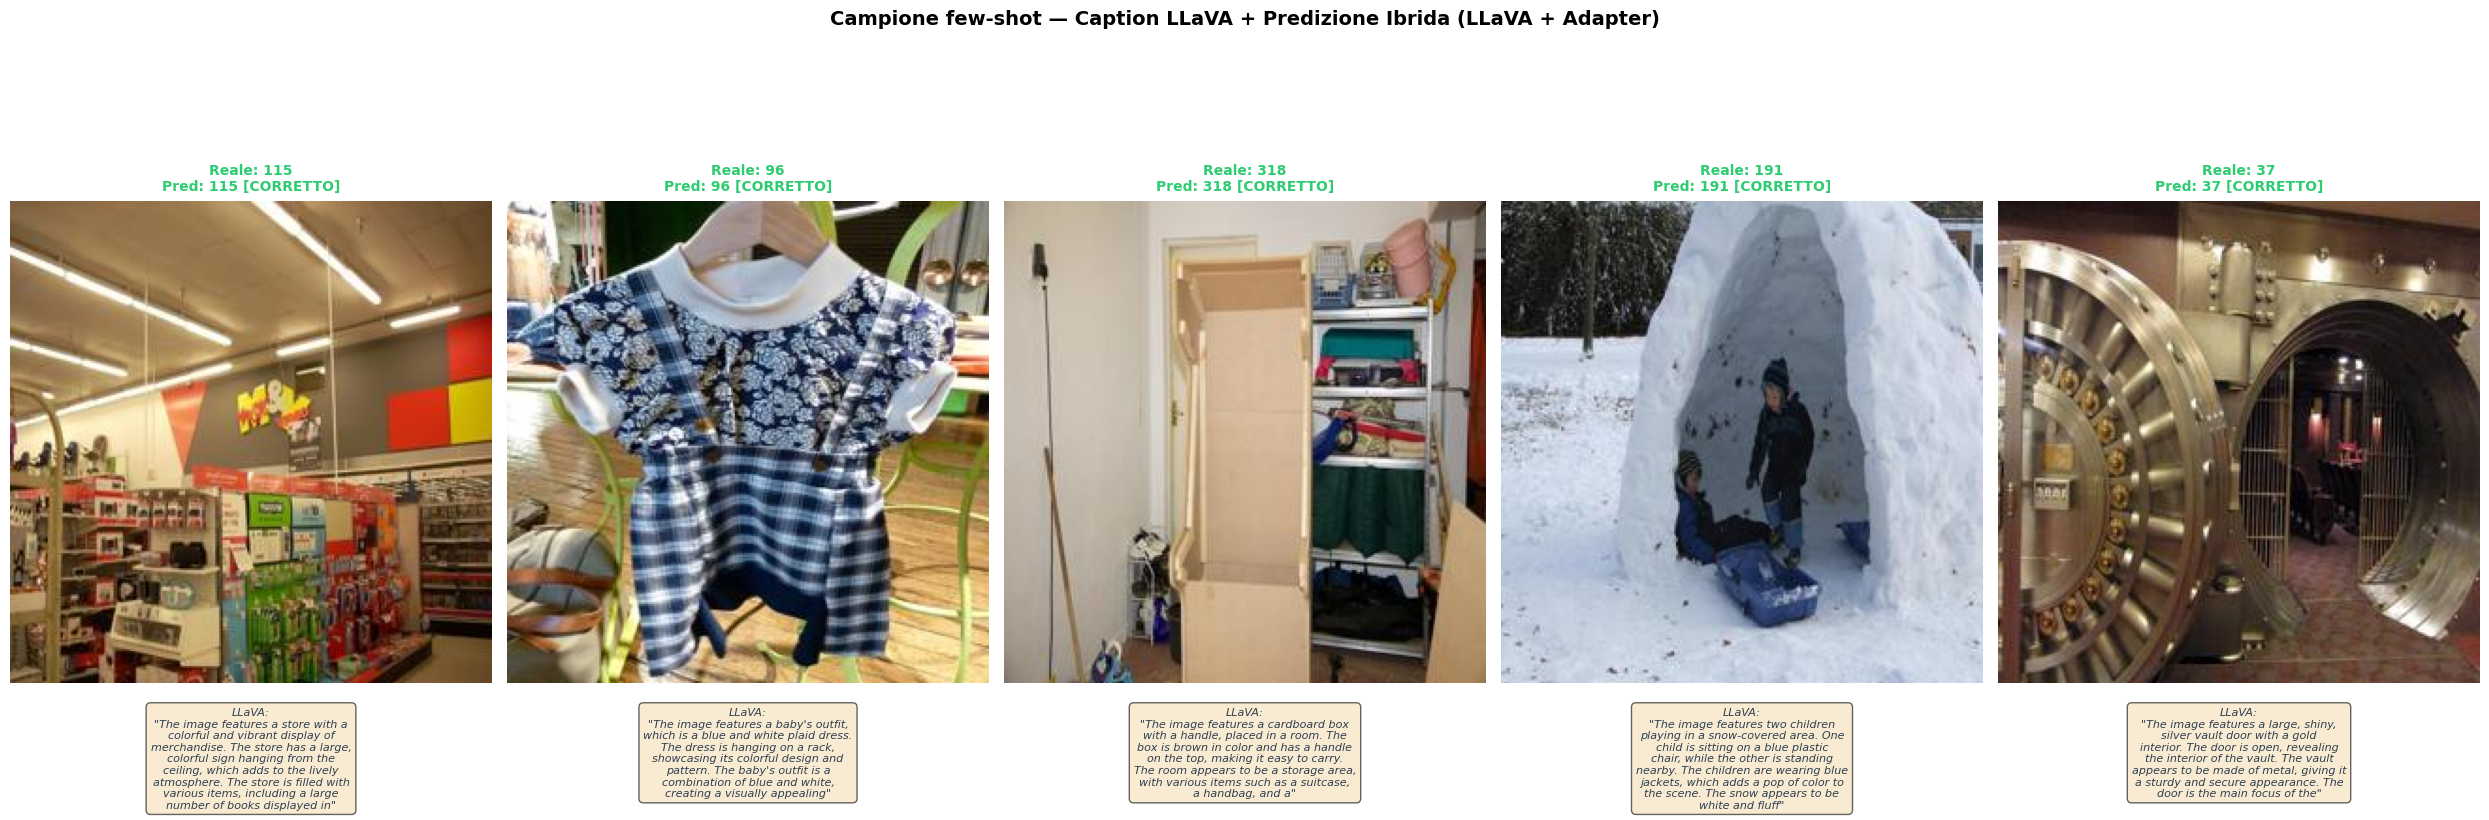


Salvato in outputs\fewshot_sample_predictions.png


In [15]:
@torch.no_grad()
def show_fewshot_predictions(dataset, clip_model, adapter_clf,
                              llava_model, llava_processor,
                              n_way=5, n_shot=5, n_images=5, seed=None):
    """
    Mostra n_images immagini casuali con:
    - Caption generata da LLaVA
    - Label reale
    - Predizione few-shot ibrida (prototipi LLaVA da support + Adapter su query)
      bordo verde=corretta, rosso=sbagliata
    Stesso formato visivo della cella 4b (zero-shot), ma con metodo few-shot.
    """
    if seed is not None:
        random.seed(seed)

    clip_model.eval()
    adapter_clf.eval()
    llava_model.eval()

    # Costruisci un episodio sintetico: scegli n_way classi, n_shot support per classe
    class_to_indices = {}
    for idx, label in enumerate(dataset.labels):
        class_to_indices.setdefault(label, []).append(idx)
    valid_classes = [c for c, idxs in class_to_indices.items() if len(idxs) >= n_shot + n_images]
    chosen_classes = random.sample(valid_classes, n_way)

    # Costruisci prototipi testuali LLaVA per le n_way classi dell'episodio
    print("Costruendo prototipi LLaVA per l'episodio few-shot...")
    text_protos = []
    local_to_global = {}
    for local_idx, cls in enumerate(chosen_classes):
        local_to_global[local_idx] = cls
        support_idxs = random.sample(class_to_indices[cls], n_shot)
        caps = []
        for i in support_idxs:
            row = dataset.df.iloc[i]
            p = dataset._resolve_path(row["filename"])
            cap = llava_caption(Image.open(p).convert("RGB"), llava_processor, llava_model)
            if not _is_looping(cap):
                caps.append(cap)
        if not caps:
            caps = ["a photo of an object"]
        toks  = clip.tokenize(caps, truncate=True).to(DEVICE)
        feats = encode_text_tokens(clip_model, toks)
        text_protos.append(F.normalize(feats.mean(dim=0), dim=-1))
        print(f"  Classe {dataset.idx_to_class[cls]}: {len(caps)} caption")
    text_protos = torch.stack(text_protos)  # [n_way, 768]

    # Scegli n_images query dalle classi dell'episodio (una per classe se possibile)
    query_indices = []
    for cls in chosen_classes:
        remaining = [i for i in class_to_indices[cls] if i not in
                     random.sample(class_to_indices[cls], n_shot)]
        query_indices.append(random.choice(remaining))

    import matplotlib.pyplot as plt
    import textwrap

    fig, axes = plt.subplots(1, n_images, figsize=(5 * n_images, 8))
    if n_images == 1:
        axes = [axes]

    fig.suptitle("Campione few-shot — Caption LLaVA + Predizione Ibrida (LLaVA + Adapter)",
                 fontsize=14, fontweight="bold", y=1.02)

    for ax, (local_idx, idx) in zip(axes, enumerate(query_indices)):
        row     = dataset.df.iloc[idx]
        path    = dataset._resolve_path(row["filename"])
        pil_img = Image.open(path).convert("RGB")
        true_cls = dataset.idx_to_class[dataset.labels[idx]]

        # Caption LLaVA per la query
        print(f"Generando caption per classe {true_cls}...")
        caption = llava_caption(pil_img, llava_processor, llava_model)

        # Predizione few-shot: Adapter + prototipi LLaVA dell'episodio
        img_tensor = clip_preprocess(pil_img).unsqueeze(0).to(DEVICE)
        q_raw   = encode_images(clip_model, img_tensor)
        q_feat  = F.normalize(
            (1 - adapter_clf.alpha) * q_raw +
            adapter_clf.alpha * adapter_clf.adapter.net(q_raw), dim=-1
        )
        logits   = 100.0 * q_feat @ text_protos.T
        pred_local = logits.argmax(dim=-1).item()
        pred_cls   = dataset.idx_to_class[chosen_classes[pred_local]]
        correct    = (chosen_classes[pred_local] == dataset.labels[idx])

        # Plot
        ax.imshow(pil_img)
        ax.axis("off")

        color = "#2ecc71" if correct else "#e74c3c"
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(color)
            spine.set_linewidth(6)

        status = "CORRETTO" if correct else "SBAGLIATO"
        ax.set_title(
            f"Reale: {true_cls}\nPred: {pred_cls} [{status}]",
            color=color, fontsize=10, fontweight="bold", pad=8
        )

        wrapped = "\n".join(textwrap.wrap(caption, width=38))
        ax.text(
            0.5, -0.05,
            f'LLaVA:\n"{wrapped}"',
            color="#2c3e50", ha="center", va="top",
            transform=ax.transAxes, fontsize=8, style="italic",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="wheat", alpha=0.6),
        )

    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, "fewshot_sample_predictions.png")
    plt.savefig(out_path, bbox_inches="tight", dpi=120)
    plt.show()
    print(f"\nSalvato in {out_path}")


# ── Lancia la visualizzazione few-shot ───────────────────────────────────────
show_fewshot_predictions(
    train_dataset,
    clip_model,
    adapter_clf,
    llava_model,
    llava_processor,
    n_way=5,
    n_shot=5,
    n_images=5,
    seed=SEED,
)


## 12 — Confronto finale tra tutti i metodi

Questa cella esegue la valutazione completa del metodo ibrido sui 100 episodi sintetici e produce il riepilogo finale con i risultati di tutti i metodi testati nel notebook.

**Differenza tra CLIP+Adapter e Ibrido few-shot:**
- CLIP+Adapter usa prototipi LLaVA costruiti sull'intero training set e valutati in classificazione chiusa (tutte le classi sempre presenti)
- Il metodo ibrido costruisce prototipi LLaVA **per episodio** sulle sole immagini di support disponibili (setting few-shot genuino, classi diverse ad ogni episodio)

Il riepilogo finale mostra il miglioramento assoluto del metodo ibrido rispetto alla baseline zero-shot.


In [16]:
set_seed(SEED)

# Metodo ibrido: LLaVA prototipi + adapter query
hybrid_acc = evaluate_episodes(
    synthetic_eps, clip_model, adapter_clf,
    llava_model, llava_processor,
    name="LLaVA+Adapter (ibrido)",
)

# ── Riepilogo ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print(f"  Zero-shot LLaVA:         {zs_acc:.2f}%   (nessun training)")
print(f"  Linear Probe:            {lp_acc:.2f}%   (classificatore lineare)")
print(f"  CLIP+Adapter:            {adapter_acc:.2f}%   (adapter trainato)")
print(f"  LLaVA+Adapter few-shot:  {hybrid_acc:.2f}%   (metodo ibrido finale)")
print("=" * 55)
print(f"  Miglioramento vs zero-shot: {hybrid_acc - zs_acc:+.2f}%")
print("=" * 55)


[LLaVA+Adapter (ibrido)]:   0%|          | 0/100 [00:00<?, ?it/s]

  Ep 10 — parziale: 91.07%
  Ep 20 — parziale: 93.13%
  Ep 30 — parziale: 92.71%
  Ep 40 — parziale: 92.83%
  Ep 50 — parziale: 91.89%
  Ep 60 — parziale: 92.27%
  Ep 70 — parziale: 93.05%
  Ep 80 — parziale: 93.08%
  Ep 90 — parziale: 93.04%
  Ep 100 — parziale: 93.12%

Accuracy LLaVA+Adapter (ibrido): 93.12% (6984/7500)

  Zero-shot LLaVA:         44.76%   (nessun training)
  Linear Probe:            98.39%   (classificatore lineare)
  CLIP+Adapter:            99.50%   (adapter trainato)
  LLaVA+Adapter few-shot:  93.12%   (metodo ibrido finale)
  Miglioramento vs zero-shot: +48.36%


## Note finali

### Architettura della pipeline

```
Immagini di support
       │
       ▼
   LLaVA 1.5-7B          CLIP ViT-L/14 (frozen)
   (caption testuale)           │
       │                        │ text encoder
       ▼                        ▼
  Testo descrittivo    Embedding testuale
       └──────────────────────►
                        Media L2-norm
                               │
                               ▼
                        Prototipo di classe [768]
                               ▲
                               │
Immagini di query ────► CLIP visual encoder ────► CLIP Adapter ────► Feature adattata [768]
                                                   (residual, α=0.2)
                               │
                               ▼
                        Cosine similarity → argmax → Predizione
```

### Guida ai file di output

| File | Contenuto |
|---|---|
| `outputs/llava_text_features.pt` | Prototipi testuali LLaVA per tutte le classi `[N_cls, 768]` |
| `outputs/clip_features.pt` | Feature visive CLIP cached (train + test) |
| `outputs/linear_probe.pt` | Pesi del classificatore lineare |
| `outputs/clip_adapter.pt` | Pesi dell'Adapter addestrato |
| `outputs/sample_predictions.png` | Visualizzazione 5 immagini zero-shot (cella 4b) |
| `outputs/fewshot_episode_viz.png` | Visualizzazione episodio few-shot (cella 11) |
| `outputs/hybrid_predictions.csv` | Predizioni per la validazione ufficiale |

### Specifiche della macchina, delle librerie e delle versioni CUDA e PyTorch sulla quale ho testato il codice

- GPU con 8 GB VRAM RTX 5070 Laptop
- CUDA 12.x, PyTorch ≥ 2.1, `transformers ≥ 4.37`, `bitsandbytes ≥ 0.41`, `open_clip_torch`
- Dataset AML nella struttura `AMLdataset/release/` con `train.csv`, `images/`, `test_episodes_release.csv`
